In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
go_dna = np.load( path + 'go_dna_dataset.npz')

In [3]:
investigate_dataset(go_dna)

['X', 'y', 'genes']

Array shapes:
X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [4]:
pca_embeddings = create_embedding_dataframe(go_dna['X'], go_dna['genes'])
pca_embeddings

PCA embeddings shape: (3697, 2048)
Total explained variance by PCA 88.03%


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484431,19.997160,-3.263608,6.096014,2.878447,2.100398,4.996948,3.763486,-2.090844,4.035175,...,0.617722,0.968765,-1.703848,-0.363270,0.672754,0.343156,1.627387,-0.869162,0.632318,0.232912
FGR,-9.459985,17.357239,-2.683443,-1.475241,5.934606,0.881287,4.911139,-0.139791,5.210980,2.031819,...,-0.091795,-0.947990,0.462464,-0.689011,-0.172014,0.477480,-1.196809,-0.947283,0.552851,1.467085
CFH,8.703357,23.714712,-4.040006,9.490277,-7.429663,3.554265,-0.899414,-2.731828,-10.455575,5.410160,...,-0.620676,0.440182,1.238525,-0.715103,0.083986,-0.796098,-0.383142,-0.317290,0.252638,0.486222
NFYA,15.312555,-8.760282,-8.302467,0.726642,-4.641839,-10.267831,-7.944366,3.540923,4.940647,-1.913206,...,-0.182304,0.267871,0.187304,-0.490240,-0.180890,0.382661,-0.043000,-0.131475,0.407531,-0.752207
CFTR,20.702248,-18.581873,-19.757996,0.525897,8.216555,4.778801,-9.161351,-4.210886,-1.544958,9.986674,...,-0.156054,0.274989,-0.422679,0.269977,0.194285,-0.284593,-0.477410,0.499855,0.179772,0.186010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407382,5.946106,-1.468829,-10.506923,5.137057,-4.193375,-4.807844,-5.273240,-5.704340,-1.174074,...,-0.053226,-0.413769,-0.143454,-0.055412,0.652148,0.047356,-0.261686,-0.030675,0.057665,-0.169753
CPHXL2,-14.601638,-6.739908,-9.937533,-7.373097,-5.923035,-6.634359,-1.230287,-2.815695,-2.358850,-0.869905,...,-0.406365,-0.058734,-0.223958,0.631730,0.396559,0.083072,-0.633401,-0.485511,0.122412,-0.295806
C8orf44-SGK3,-2.840687,14.210390,-2.690784,6.343092,0.053459,2.255720,3.574327,5.975211,-1.967672,2.915341,...,-0.712759,-0.457149,0.161125,0.057670,0.124332,-2.638488,-0.619614,-1.034732,0.836978,0.281738


In [5]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [ ]:
cancer_gene_columns = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(cancer_gene_columns, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484431,19.997160,-3.263608,6.096014,2.878447,2.100398,4.996948,3.763486,-2.090844,4.035175,...,0.672754,0.343156,1.627387,-0.869162,0.632318,0.232912,False,False,False,False
FGR,-9.459985,17.357239,-2.683443,-1.475241,5.934606,0.881287,4.911139,-0.139791,5.210980,2.031819,...,-0.172014,0.477480,-1.196809,-0.947283,0.552851,1.467085,False,False,False,False
CFH,8.703357,23.714712,-4.040006,9.490277,-7.429663,3.554265,-0.899414,-2.731828,-10.455575,5.410160,...,0.083986,-0.796098,-0.383142,-0.317290,0.252638,0.486222,False,False,False,False
NFYA,15.312555,-8.760282,-8.302467,0.726642,-4.641839,-10.267831,-7.944366,3.540923,4.940647,-1.913206,...,-0.180890,0.382661,-0.043000,-0.131475,0.407531,-0.752207,False,False,False,False
CFTR,20.702248,-18.581873,-19.757996,0.525897,8.216555,4.778801,-9.161351,-4.210886,-1.544958,9.986674,...,0.194285,-0.284593,-0.477410,0.499855,0.179772,0.186010,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL3,-15.490884,-0.406354,-2.594781,-9.861933,-1.599663,-4.762601,-4.898874,-4.700206,-5.546379,-3.239688,...,-0.000313,0.573271,-0.431094,-1.398592,0.153716,0.087805,False,False,False,False
SSTR3,4.326700,-5.663862,12.208852,9.123993,1.093354,0.461676,1.553362,-4.534098,-0.840401,-7.031991,...,0.349126,-0.405871,-0.203125,-0.342810,-0.118350,0.236448,False,False,False,False
MYO19,5.753087,-14.638465,-17.008127,9.437111,5.492779,7.279740,1.104653,-5.904331,-3.853758,0.653559,...,0.480928,0.245065,1.355237,-0.409993,-1.098947,0.636869,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [8]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    2956
True      313
Name: count, dtype: int64

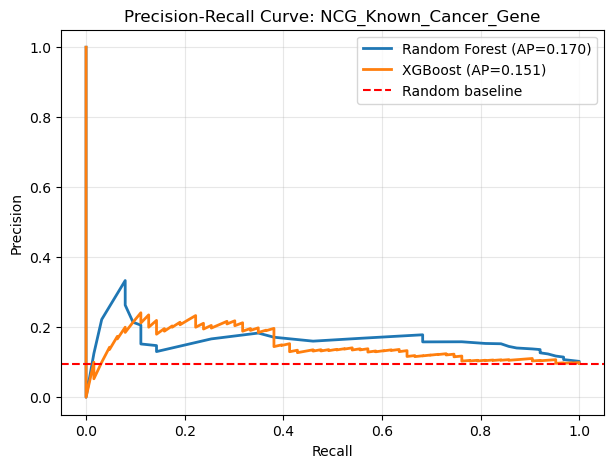

Random Forest - auPRC: 0.170
XGBoost - auPRC: 0.151



In [9]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [10]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    2899
True      370
Name: count, dtype: int64

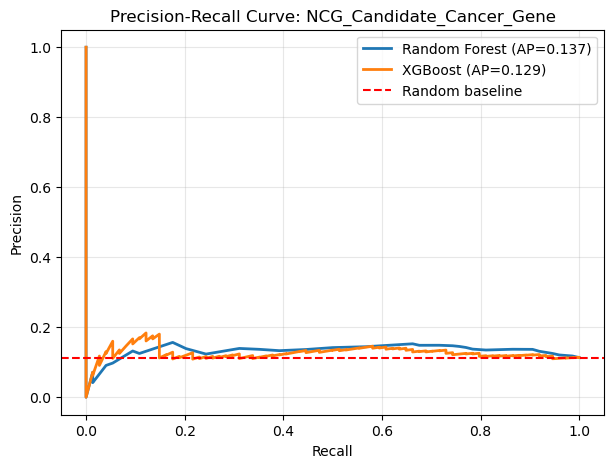

Random Forest - auPRC: 0.137
XGBoost - auPRC: 0.129



In [11]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [12]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    3016
True      253
Name: count, dtype: int64

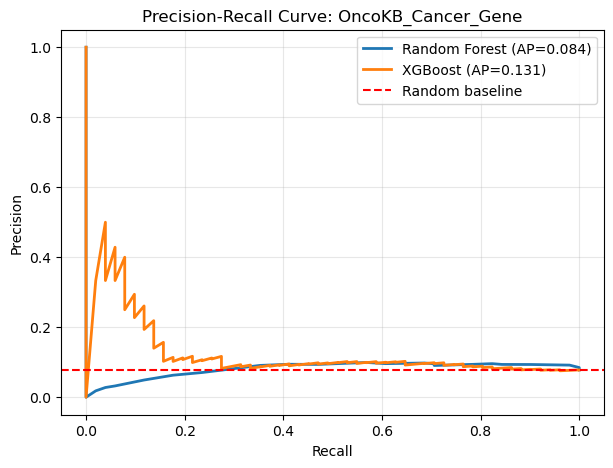

Random Forest - auPRC: 0.084
XGBoost - auPRC: 0.131



In [13]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [14]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    3134
True      135
Name: count, dtype: int64

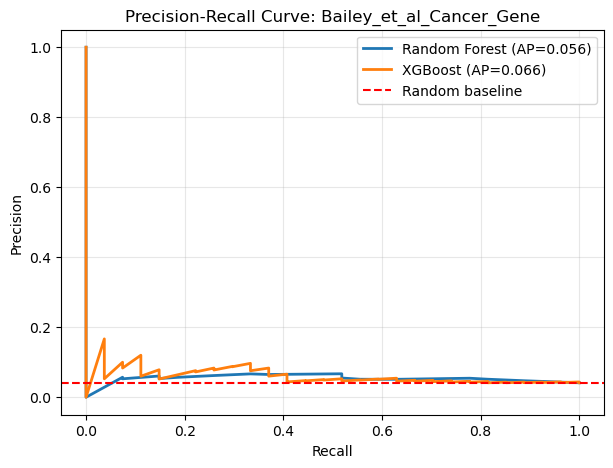

Random Forest - auPRC: 0.056
XGBoost - auPRC: 0.066



In [15]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')